# QAOA for Maximum Cut — Chapter 3 Part II : Circuits, Classical Baselines, and Landscape

Second half of Chapter 3.

**Trotter view.** The alternating $U_C(\gamma) U_B(\beta)$ structure of the QAOA ansatz is the first-order Lie–Trotter splitting of an adiabatic interpolation between $H_B$ and $H_C$. Splitting is necessary because $[H_B, H_C] \neq 0$.

**Gate decomposition.** Each edge term $e^{i(\gamma/2) Z_i Z_j}$ in $U_C(\gamma)$ is implemented as a **CNOT – $R_Z(-\gamma)$ – CNOT** block. The identity follows from $\text{CNOT}(I \otimes Z)\text{CNOT} = Z \otimes Z$: sandwiching a single-qubit $R_Z$ between two CNOTs promotes it to a two-qubit $ZZ$-rotation. Per layer on $|E|$ edges: $2|E|$ CNOTs + $|E|$ $R_Z$ gates. Mixer: $n$ single-qubit $R_X(2\beta)$ gates, no entangling gates.

**Classical benchmarks.**
- **Greedy** — process vertices in order, each joins the side cutting more assigned neighbours. Ratio $\geq 0.5$.
- **Greedy best-of-5** — five random orderings, keep best. Still cheap, much stronger than single-pass.
- **Goemans–Williamson (GW)** — SDP relaxation + random hyperplane rounding. Ratio $\geq 0.8786$; tight under the Unique Games Conjecture.

**Locality limitation of shallow QAOA.** After $p$ layers, qubit $i$ has only interacted with qubits within graph distance $p$ (Bravyi et al. 2021). Shallow QAOA therefore cannot distinguish graphs that agree within radius $p$ of every vertex.

**Barren plateaus.** Gradient variance can decay exponentially with $n$ on highly expressive ansätze (McClean et al. 2018). MaxCut at low depth is mostly shielded by its 2-local structure; we state the result and verify the modest decay numerically at $n \le 12$.

**Numerical error sources:** floating-point ($O(d\varepsilon_{\text{mach}})$, negligible at our depths), shot noise ($O(|E|/\sqrt{S})$ on hardware), optimiser convergence error (solver-dependent), and the inter-layer Trotter splitting that is the QAOA ansatz itself (the within-layer decomposition is exact).

See [README.md](README.md) in this folder for the full Chapter 3 walkthrough.

---
## 1. Classical Algorithms

### 1.1 Random Assignment

Assign each vertex independently to $S$ or $\bar{S}$ with probability $\frac{1}{2}$ each.

**Analysis.** For any edge $(i,j)$:

$$\Pr[z_i\neq z_j] = \Pr[z_i=0,z_j=1]+\Pr[z_i=1,z_j=0] = \frac{1}{4}+\frac{1}{4}=\frac{1}{2}$$

By linearity of expectation: $\mathbb{E}[C(z)]=\sum_{(i,j)\in E}\frac{1}{2}=\frac{|E|}{2}$, giving **approximation ratio $= 0.5$** for any graph.

**Limitation.** The ratio is exactly $0.5$ and cannot be improved by repeating — each trial is independent with the same distribution. Random assignment gives zero information about which vertices *should* be on the same side.

---
### 1.2 Greedy

Process vertices in a fixed order $v_1,v_2,\ldots,v_n$. Assign each vertex to whichever side maximises the number of edges cut *with already-assigned neighbours*.

**Step-by-step on $C_4$** (order: $0\to 1\to 2\to 3$):

| Step | Vertex | Neighbours assigned | Side chosen | Reason |
|------|--------|--------------------|--------------|---------|
| 1 | $0$ | none | $S$ (0) | arbitrary |
| 2 | $1$ | $0\in S$ | $\bar{S}$ (1) | cuts edge $(0,1)$ |
| 3 | $2$ | $1\in\bar{S}$ | $S$ (0) | cuts edge $(1,2)$ |
| 4 | $3$ | $2\in S$, $0\in S$ | $\bar{S}$ (1) | cuts edges $(2,3)$ and $(3,0)$ |

Result: $\{0,2\}$ vs $\{1,3\}$ → cut $= 4$ (optimal for $C_4$).

But this works because $C_4$ is bipartite. On a harder graph, greedy gets stuck:

**Example failure.** Triangle $K_3$: vertices $\{0,1,2\}$, edges $(0,1),(1,2),(2,0)$. MaxCut $= 2$. Greedy with order $0\to 1\to 2$:
- $0\to S$, $1\to\bar{S}$ (cuts $(0,1)$), $2$: neighbour $1\in\bar{S}$, $0\in S$ → tie → goes to $S$. Cut $=\{(0,1),(2,1)\}=2$. OK here.
- But with order $0\to 2\to 1$: $0\to S$, $2\to\bar{S}$ (cuts $(0,2)$), $1$: neighbour $0\in S$, $2\in\bar{S}$ → tie → $S$. Cut $=\{(0,2),(1,2)\}=2$. Still OK.

For larger graphs, greedy's **myopia** — it never reconsidered early decisions — causes systematic failures near triangles and odd cycles (frustrated regions).

**Formal guarantee.** For any graph, greedy achieves ratio $\geq 0.5$. This follows because at each step, the chosen side has $\geq$ as many assigned neighbours on the opposite side as on the same side — so at least half the adjacent assigned edges are cut.

Greedy trace on C4 (order: 0->1->2->3):
  Assign vertex 0 -> S   cumulative cut = 2
  Assign vertex 1 -> Sbar   cumulative cut = 3
  Assign vertex 2 -> S   cumulative cut = 4
  Assign vertex 3 -> Sbar   cumulative cut = 4
Final cut: 4/4



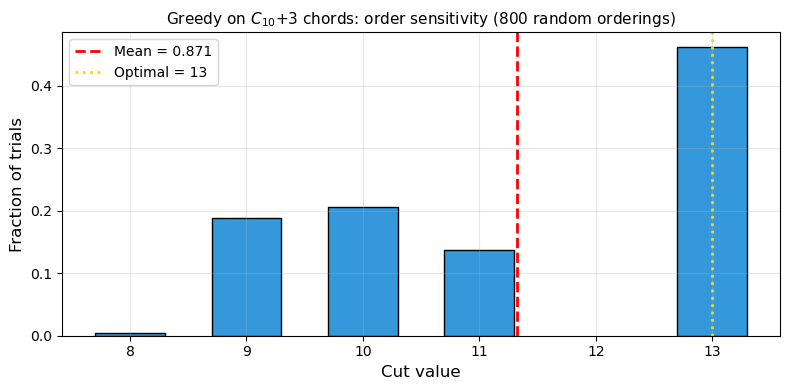

Greedy on C10+chords: mean ratio=0.871, best=1.000, worst=0.615


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def cut_val(bits, edges):
    return sum(int(bits[i])!=int(bits[j]) for i,j in edges)

def greedy_cut(n, edges, order):
    """Assign each vertex to maximise cuts with already-assigned neighbours."""
    assignment = [-1]*n
    steps = []
    for v in order:
        in_S    = sum(1 for i,j in edges
                      if (i==v and assignment[j]==1) or (j==v and assignment[i]==1))
        in_Sbar = sum(1 for i,j in edges
                      if (i==v and assignment[j]==0) or (j==v and assignment[i]==0))
        if in_S == 0 and in_Sbar == 0:
            assignment[v] = 0
        else:
            assignment[v] = 1 if in_Sbar > in_S else 0
        steps.append((v, assignment[v], cut_val(assignment, edges)))
    return cut_val(assignment, edges), assignment, steps

# Trace greedy on C4
n4 = 4; e4 = [(0,1),(1,2),(2,3),(3,0)]
val, assign, steps = greedy_cut(n4, e4, [0,1,2,3])
print('Greedy trace on C4 (order: 0->1->2->3):')
side_name = {0:'S', 1:'Sbar'}
for v, side, cum_cut in steps:
    print(f'  Assign vertex {v} -> {side_name[side]}   cumulative cut = {cum_cut}')
print(f'Final cut: {val}/{max(cut_val(list(range(16)), e4) for _ in [None])}\n')

# Show sensitivity to vertex order on C10+chords
G2 = nx.cycle_graph(10); G2.add_edges_from([(0,5),(2,7),(4,9)])
e2 = list(G2.edges()); n2=10; cmax2=13

greedy_cuts = [greedy_cut(n2, e2, rng.permutation(n2))[0] for _ in range(800)]

fig, ax = plt.subplots(figsize=(8, 4))
unique, cnts = np.unique(greedy_cuts, return_counts=True)
ax.bar(unique, cnts/800, color='#3498DB', edgecolor='black', width=0.6)
ax.axvline(np.mean(greedy_cuts), color='red', lw=2, ls='--',
           label=f'Mean = {np.mean(greedy_cuts)/cmax2:.3f}')
ax.axvline(cmax2, color='gold', lw=2, ls=':',
           label=f'Optimal = {cmax2}')
ax.set_xlabel('Cut value', fontsize=12)
ax.set_ylabel('Fraction of trials', fontsize=12)
ax.set_title(r'Greedy on $C_{10}$+3 chords: order sensitivity (800 random orderings)',
             fontsize=11)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Greedy on C10+chords: mean ratio={np.mean(greedy_cuts)/cmax2:.3f}, '
      f'best={max(greedy_cuts)/cmax2:.3f}, worst={min(greedy_cuts)/cmax2:.3f}')

---
### 1.3 Goemans–Williamson (SDP Rounding)

This is the classical state of the art for MaxCut.

#### Step 1 — Relax binary to geometric

The MaxCut integer program is:

$$\max\sum_{(i,j)\in E}\frac{1-s_is_j}{2}, \qquad s_i\in\{-1,+1\}$$

GW replaces each scalar $s_i\in\{-1,+1\}$ with a **unit vector** $v_i\in\mathbb{R}^n$, $\|v_i\|=1$. The product $s_is_j$ becomes the dot product $v_i\cdot v_j$. The relaxed problem is:

$$\max\sum_{(i,j)\in E}\frac{1-v_i\cdot v_j}{2}, \qquad \|v_i\|=1$$

**Why is this easier?** The original problem is over a discrete set $\{-1,+1\}^n$ (NP-hard). The relaxed problem is over a continuous manifold of unit vectors — it is a **semidefinite program (SDP)**, which is convex and solvable in polynomial time.

#### Step 2 — Reformulate as SDP

Let $X_{ij}=v_i\cdot v_j$. Then $X$ is a **positive semidefinite matrix** with ones on the diagonal (since $v_i\cdot v_i=\|v_i\|^2=1$). The problem becomes:

$$\max\sum_{(i,j)\in E}\frac{1-X_{ij}}{2} \qquad \text{s.t.}\quad X\succeq 0,\quad X_{ii}=1$$

This is a standard SDP — a linear objective over the convex cone of PSD matrices. Interior-point methods solve it in $O(n^{3.5})$ time.

#### Step 3 — Hyperplane rounding

The SDP gives us vectors $v_0,\ldots,v_{n-1}\in\mathbb{R}^n$. We need to round them back to a binary assignment. The GW rounding:

1. Sample a random unit vector $r\in\mathbb{R}^n$ (from the uniform distribution on the sphere).
2. Assign $z_i = 1$ if $v_i\cdot r\geq 0$, else $z_i = 0$.

Geometrically: a random hyperplane through the origin partitions the vectors. Vectors on the same side get the same label.

#### Step 4 — Approximation guarantee

For edge $(i,j)$, let $\theta_{ij}=\arccos(v_i\cdot v_j)\in[0,\pi]$ be the angle between the vectors. The probability that the hyperplane separates $v_i$ and $v_j$ is:

$$\Pr[z_i\neq z_j] = \frac{\theta_{ij}}{\pi}$$

The SDP objective gives a value $\frac{1-v_i\cdot v_j}{2}=\frac{1-\cos\theta_{ij}}{2}$. The ratio of the rounding probability to the SDP value is:

$$\frac{\theta/\pi}{(1-\cos\theta)/2} \geq \alpha_{\mathrm{GW}} \approx 0.8786 \quad \forall\,\theta\in[0,\pi]$$

This minimum is achieved at $\theta\approx 2.331$ radians. Therefore:

$$\mathbb{E}[C_{\mathrm{GW}}] = \sum_{(i,j)\in E}\Pr[z_i\neq z_j] \geq 0.8786\sum_{(i,j)\in E}\frac{1-v_i\cdot v_j}{2} \geq 0.8786\cdot C_{\mathrm{OPT}}$$

**Limitations:**
- Cannot achieve ratio $>0.8786$ in polynomial time (unless Unique Games Conjecture fails)
- SDP solve is $O(n^{3.5})$ — impractical for $n>10^4$
- Rounding is randomised; the guarantee holds in expectation

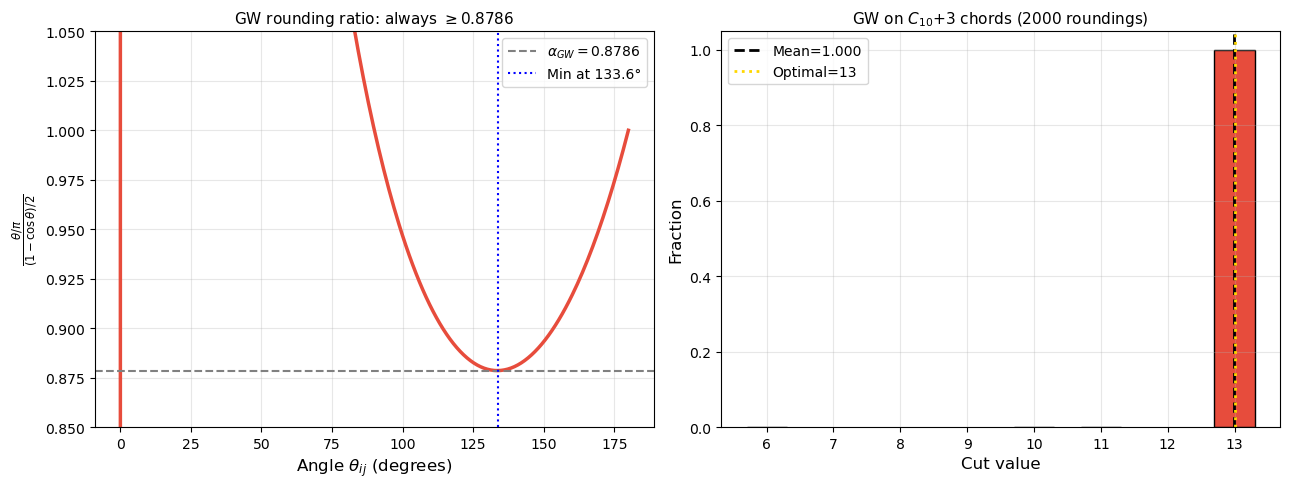

SDP upper bound: 13.0000
GW mean ratio: 0.9995
Theoretical guarantee: >= 0.8786


In [2]:
import cvxpy as cp

# GW SDP on C4 and C10+chords
def gw_sdp(n, edges, n_rounds=2000):
    X = cp.Variable((n,n), symmetric=True)
    prob = cp.Problem(
        cp.Maximize(sum(0.5*(1-X[i,j]) for i,j in edges)),
        [X >> 0] + [X[i,i]==1 for i in range(n)]
    )
    prob.solve(solver=cp.SCS, verbose=False)
    # Robust PSD projection
    eigvals, eigvecs = np.linalg.eigh(X.value)
    eigvals = np.maximum(eigvals, 1e-6)
    V = eigvecs @ np.diag(np.sqrt(eigvals))  # V V^T = X
    # Hyperplane rounding
    cuts = []
    for _ in range(n_rounds):
        r = rng.standard_normal(n)
        r /= np.linalg.norm(r)
        bits = (V @ r >= 0).astype(int)
        cuts.append(cut_val(bits, edges))
    return cuts, prob.value

# Visualise: probability that each edge is cut vs angle between vectors
theta = np.linspace(0, np.pi, 300)
ratio_fn = (theta/np.pi) / ((1-np.cos(theta))/2 + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(np.degrees(theta), ratio_fn, '#E74C3C', lw=2.5)
axes[0].axhline(0.8786, color='gray', ls='--', lw=1.5, label=r'$\alpha_{GW}=0.8786$')
theta_min = theta[np.argmin(ratio_fn[10:])+10]
axes[0].axvline(np.degrees(theta_min), color='blue', ls=':', lw=1.5,
                label=f'Min at {np.degrees(theta_min):.1f}°')
axes[0].set_xlabel(r'Angle $\theta_{ij}$ (degrees)', fontsize=12)
axes[0].set_ylabel(r'$\frac{\theta/\pi}{(1-\cos\theta)/2}$', fontsize=12)
axes[0].set_title('GW rounding ratio: always $\geq 0.8786$', fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.85, 1.05)

# GW on C10+chords
gw_cuts, sdp_val = gw_sdp(n2, e2, n_rounds=2000)
unique_gw, cnts_gw = np.unique(gw_cuts, return_counts=True)
axes[1].bar(unique_gw, cnts_gw/2000, color='#E74C3C', edgecolor='black', width=0.6)
axes[1].axvline(np.mean(gw_cuts), color='black', lw=2, ls='--',
                label=f'Mean={np.mean(gw_cuts)/cmax2:.3f}')
axes[1].axvline(cmax2, color='gold', lw=2, ls=':',
                label=f'Optimal={cmax2}')
axes[1].set_xlabel('Cut value', fontsize=12)
axes[1].set_ylabel('Fraction', fontsize=12)
axes[1].set_title(r'GW on $C_{10}$+3 chords (2000 roundings)', fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'SDP upper bound: {sdp_val:.4f}')
print(f'GW mean ratio: {np.mean(gw_cuts)/cmax2:.4f}')
print(f'Theoretical guarantee: >= 0.8786')

---
## 2. Why Is GW Hard for QAOA to Beat?

GW has two structural advantages over QAOA at small $p$:

**1. GW is a global algorithm.** The SDP sees the *entire* graph simultaneously — the solution matrix $X$ encodes pairwise relationships between all $\binom{n}{2}$ pairs of vertices.

**2. QAOA at depth $p$ is local.** After $p$ layers, qubit $i$ has only interacted with qubits within distance $p$ in the graph. Formally (Bravyi et al. 2020): QAOA at depth $p$ cannot distinguish two graphs that agree within radius $p$ of every vertex. This is a fundamental **locality limitation** — for large graphs, small $p$ QAOA is provably no better than algorithms that only see a local neighbourhood.

**Known result.** Farhi et al. (2014) showed that QAOA $p=1$ achieves ratio $\geq 0.6924$ on 2-regular graphs (cycles). GW achieves $\geq 0.8786$ on any graph. The gap is real.

**Open question.** Can QAOA at $p=\mathrm{poly}(n)$ achieve ratio $>0.8786$? Unknown.

---
## 3. From Adiabatic Trotter to the QAOA Ansatz

The QAOA signature — alternating $e^{-i\gamma H_C}$ and $e^{-i\beta H_B}$ layers — is not arbitrary. It is the **Lie–Trotter splitting** of an adiabatic evolution between $H_B$ and $H_C$. This section explains the connection in three short steps; the gate-level circuit for each individual layer is derived in §4.

### 3.1 Adiabatic baseline

Quantum adiabatic optimisation prepares the ground state of $H_C$ by slowly interpolating from $H_B = -\sum_i X_i$ (whose ground state $|+\rangle^{\otimes n}$ is easy to prepare) to $H_C$ over time $T$:

$$H(t) \;=\; (1 - s(t))\,H_B \;+\; s(t)\,H_C, \qquad s(0) = 0,\ s(T) = 1.$$

If $T$ is long compared to the inverse minimum spectral gap, the adiabatic theorem guarantees the system stays in the instantaneous ground state and ends in the ground state of $H_C$ — the MaxCut solution.

### 3.2 Trotter splitting because $[H_B, H_C] \neq 0$

Implementing $U(T) = \mathcal{T}\exp\!\left(-i\int_0^T H(t)\,dt\right)$ as a circuit requires discretisation. Cut $T$ into $p$ steps of length $\Delta t$ and approximate $H(t)$ as piecewise constant with values $a_k = 1 - s_k$, $b_k = s_k$ in step $k$. The crucial fact:

$$[H_B, H_C] \;=\; \Big[\,\sum_i X_i,\ \sum_{(i,j)\in E}\tfrac{I - Z_iZ_j}{2}\,\Big] \;\neq\; 0,$$

so the joint exponential does **not** factorise:

$$e^{-i\Delta t\,(a_k H_B + b_k H_C)} \;\neq\; e^{-i\,b_k\Delta t\,H_C}\,e^{-i\,a_k\Delta t\,H_B}.$$

The first-order **Lie–Trotter** decomposition replaces the left-hand side with the right-hand side, with error $O(\Delta t^2\,\|[H_B, H_C]\|)$ per step. Stitching $p$ steps together yields

$$U(T) \;\approx\; \prod_{k=1}^{p}\, e^{-i\,\beta_k H_B}\,e^{-i\,\gamma_k H_C}, \qquad \beta_k = a_k\Delta t,\ \gamma_k = b_k\Delta t,$$

which is exactly the QAOA ansatz. Higher-order Suzuki–Trotter splittings exist; QAOA uses the simplest first-order one.

### 3.3 What QAOA does with this view

The adiabatic-Trotter argument *fixes* $(\gamma_k, \beta_k)$ from a particular schedule $s(t)$ and step size $\Delta t$. **QAOA loosens this** — it treats $\boldsymbol\gamma, \boldsymbol\beta$ as free variational parameters tuned by a classical optimiser. So QAOA inherits the alternating structure from Trotterisation but is *not* required to follow a slow-adiabatic schedule; it can use aggressive (non-adiabatic) angle choices that reach high cut quality at very small $p$.

Two design choices fall out of this Trotter view:

- **Initial state $|+\rangle^{\otimes n}$.** The ground state of $H_B$ — the natural starting point of the adiabatic interpolation.
- **Only $U_B$ and $U_C$, no other unitaries.** They are the two Hamiltonians being interpolated; Trotter splitting demands nothing else.

The Trotter discretisation lives **between layers** (alternating $H_B$, $H_C$ steps). In contrast, the decomposition *inside* each layer — implementing $e^{-i\gamma H_C}$ as a product of edge factors $e^{-i\gamma h_e}$ — is exact, because the terms within $H_C$ commute pairwise (and likewise for $H_B$). §4 derives the explicit gate decomposition; §6.4 returns to the Trotter accounting.

---
## 4. Gate Decomposition: CNOT–$R_Z$–CNOT from First Principles

We need to implement $e^{i\frac{\gamma}{2}Z_iZ_j}$ as a circuit. This requires three steps.

### Step 1 — CNOT as a matrix

CNOT (control $i$, target $j$) flips the target qubit if the control is $|1\rangle$:

$$\mathrm{CNOT}|q_i q_j\rangle = |q_i,\, q_i\oplus q_j\rangle$$

where $\oplus$ is addition mod 2. As a $4\times 4$ matrix (in the $|00\rangle,|01\rangle,|10\rangle,|11\rangle$ basis):

$$\mathrm{CNOT} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}$$

Note $\mathrm{CNOT}^2 = I$ (applying twice undoes the flip).

### Step 2 — CNOT conjugates $Z_j$ into $Z_iZ_j$

**Claim:** $\mathrm{CNOT}_{ij}\,Z_j\,\mathrm{CNOT}_{ij} = Z_iZ_j$

**Proof by action on basis states:**

| State | After first CNOT | After $Z_j$ | After second CNOT | Net eigenvalue |
|-------|-----------------|-------------|------------------|----------------|
| $|00\rangle$ | $|00\rangle$ | $+|00\rangle$ | $+|00\rangle$ | $+1 = (+1)(+1)$ |
| $|01\rangle$ | $|01\rangle$ | $-|01\rangle$ | $-|01\rangle$ | $-1 = (+1)(-1)$ |
| $|10\rangle$ | $|11\rangle$ | $-|11\rangle$ | $-|10\rangle$ | $-1 = (-1)(+1)$ |
| $|11\rangle$ | $|10\rangle$ | $+|10\rangle$ | $+|11\rangle$ | $+1 = (-1)(-1)$ |

The net eigenvalue on $|q_iq_j\rangle$ is $(-1)^{q_i}(-1)^{q_j} = Z_iZ_j|q_iq_j\rangle$. ✓

### Step 3 — Lift to the exponential

For any matrix $A$ and invertible $P$: $e^{PAP^{-1}} = Pe^AP^{-1}$. (Proof: expand $e^{PAP^{-1}}=\sum_k\frac{(PAP^{-1})^k}{k!}=\sum_k\frac{PA^kP^{-1}}{k!}=Pe^AP^{-1}$)

Apply with $A=\frac{i\gamma}{2}Z_j$ and $P=\mathrm{CNOT}_{ij}$ (noting $\mathrm{CNOT}^{-1}=\mathrm{CNOT}$):

$$e^{i\frac{\gamma}{2}Z_iZ_j} = e^{i\frac{\gamma}{2}\cdot\mathrm{CNOT}\,Z_j\,\mathrm{CNOT}} = \mathrm{CNOT}\cdot e^{i\frac{\gamma}{2}Z_j}\cdot\mathrm{CNOT}$$

### Step 4 — Identify $e^{i\frac{\gamma}{2}Z} = R_Z(-\gamma)$

The standard $R_Z$ gate is defined as:

$$R_Z(\theta) \equiv e^{-i\frac{\theta}{2}Z} = \begin{pmatrix}e^{-i\theta/2}&0\\0&e^{i\theta/2}\end{pmatrix}$$

So $e^{i\frac{\gamma}{2}Z} = R_Z(-\gamma)$. Therefore:

$$\boxed{e^{i\frac{\gamma}{2}Z_iZ_j} = \mathrm{CNOT}_{ij}\cdot R_Z(-\gamma)_j\cdot\mathrm{CNOT}_{ij}}$$

This is **exact** — not an approximation. The mixer gate follows similarly: $e^{-i\beta X}=R_X(2\beta)$ since $R_X(\theta)\equiv e^{-i\theta X/2}$.

In [3]:
from scipy.linalg import expm

I2   = np.eye(2, dtype=complex)
Z    = np.array([[1,0],[0,-1]], dtype=complex)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)

def Rz(theta):
    return np.array([[np.exp(-1j*theta/2), 0],
                     [0,  np.exp( 1j*theta/2)]], dtype=complex)

gamma = 0.7

# Circuit: CNOT · (I ⊗ Rz(-gamma)) · CNOT
circuit = CNOT @ np.kron(I2, Rz(-gamma)) @ CNOT

# Direct: expm(i*gamma/2 * Z⊗Z)
ZZ = np.kron(Z, Z)
direct = expm(1j * gamma/2 * ZZ)

# Verify
diff = np.max(np.abs(circuit - direct))
print(f'Max |circuit - direct|: {diff:.2e}')
print('-> Decomposition is exact (circuit and direct are identical)\n')

# Step-by-step action on each basis state
print('Phase applied per basis state:')
print(f'{"State":8s} {"Cut?":6s} {"Phase (circuit)":>16s} {"Expected (γ/2·s0·s1)":>22s}')
for z in range(4):
    ket = np.zeros(4, dtype=complex); ket[z] = 1
    out = circuit @ ket
    phase = np.angle(out[z])
    q0, q1 = (z>>1)&1, z&1
    s0, s1 = 1-2*q0, 1-2*q1
    expected = gamma/2 * s0 * s1
    print(f'|{q0}{q1}>     {str(q0!=q1):6s} {phase:16.4f} {expected:22.4f}')

Max |circuit - direct|: 0.00e+00
-> Decomposition is exact (circuit and direct are identical)

Phase applied per basis state:
State    Cut?    Phase (circuit)   Expected (γ/2·s0·s1)
|00>     False            0.3500                 0.3500
|01>     True            -0.3500                -0.3500
|10>     True            -0.3500                -0.3500
|11>     False            0.3500                 0.3500


---
## 5. Barren Plateaus

For a parameterised state $|\psi_p(\boldsymbol\theta)\rangle$ optimised against a cost Hamiltonian, McClean et al. (2018) showed that the gradient

$$\frac{\partial F_p}{\partial\theta_k} = \langle\psi_p|\,i[G_k, H_C]\,|\psi_p\rangle$$

(where $G_k$ is the $k$-th gate generator) has zero mean and variance bounded by

$$\mathrm{Var}\!\left[\frac{\partial F_p}{\partial\theta_k}\right] \;\leq\; \frac{C}{b^n}, \qquad b \geq 2,$$

once the trailing part of the circuit forms a unitary 2-design. The variance decays *exponentially* in $n$, so to distinguish the gradient from zero with $S$ shots one needs $S \gtrsim |E|^2 \cdot b^n / C$ — exponentially many shots, which makes gradient-based optimisation infeasible at large $n$.

**Why this is mild for MaxCut.** The cost Hamiltonian for MaxCut is **2-local** ($H_C = \sum_e h_e$ with each $h_e$ acting on two qubits), so $\mathrm{tr}(H_C^2) = |E|$ contributes only a polynomial prefactor: $\mathrm{Var}[\partial_\theta F] \lesssim |E|/4^n$ at the 2-design limit. At low depth $p$ the QAOA circuit is *not* yet 2-design — the bound is loose, and the actual decay is closer to $O(1/\mathrm{poly}(n))$. The numerical experiment below confirms this on cycle graphs at $n \in \{4, 6, 8, 10, 12\}$, $p = 1$: the variance drops as a polynomial rather than exponentially.

**Practical consequence at our scales.** At the modest $n \le 12$ and $p \le 3$ we operate, the gradient is well inside the trainable regime. Barren plateaus are a genuine concern at $n \gtrsim 50$ or with deeper, more expressive ansätze; they are not the bottleneck here. For the full mathematical derivation (2-design argument, Haar-measure averages) see McClean et al. 2018 and Cerezo et al. 2021.

Normalised gradient variance vs n  (gradient / |E|,  p=1, FD, 400 random init):
   n    E[(∂F/∂γ)/|E|]    Var[(∂F/∂γ)/|E|]         std
   4      -0.00321      0.06245672    0.249913
   6      -0.00214      0.06347658    0.251946
   8      -0.00931      0.05462646    0.233723
  10       0.01978      0.06198596    0.248970
  12      -0.00878      0.06410341    0.253187


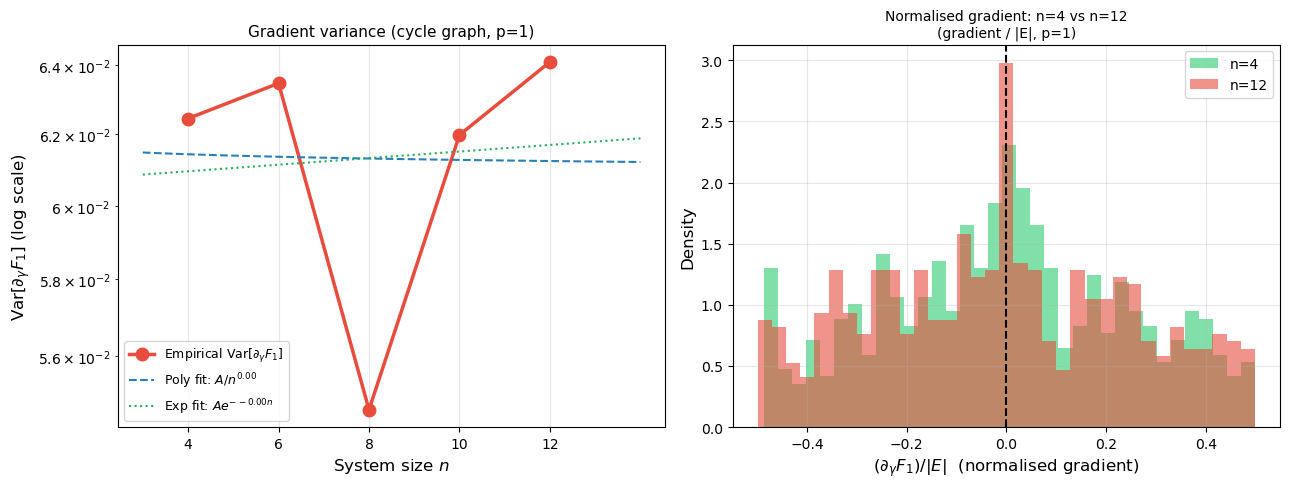

In [4]:
# Gradient variance vs system size — numerical demonstration
rng2 = np.random.default_rng(42)
n_values = [4, 6, 8, 10, 12]
n_samples = 400
h_fd = 1e-3

def build_diag(edges, n_):
    d = np.zeros(2**n_)
    for x in range(2**n_):
        bits = [(x>>i)&1 for i in range(n_)]
        d[x] = sum((bits[i]!=bits[j]) for i,j in edges)
    return d

def apply_UB(psi, beta, n_):
    c,s = np.cos(beta), np.sin(beta)
    for q in range(n_):
        psi2 = psi.reshape([2]*n_)
        psi2 = np.moveaxis(psi2,q,0).reshape(2,-1)
        psi2 = np.array([c*psi2[0]-1j*s*psi2[1], -1j*s*psi2[0]+c*psi2[1]])
        psi2 = psi2.reshape([2]*n_)
        psi = np.moveaxis(psi2,0,q).reshape(-1)
    return psi

def qaoa_p1_val(gamma, beta, diag_, n_):
    psi = np.ones(2**n_)/np.sqrt(2**n_) + 0j
    psi = np.exp(-1j*gamma*diag_)*psi
    psi = apply_UB(psi, beta, n_)
    return float(np.real(np.dot(psi.conj(), diag_*psi)))

print('Normalised gradient variance vs n  (gradient / |E|,  p=1, FD, 400 random init):')
print(f'{"n":>4s}  {"E[(∂F/∂γ)/|E|]":>16s}  {"Var[(∂F/∂γ)/|E|]":>18s}  {"std":>10s}')
grad_vars = []
for n_ in n_values:
    edges_ = list(nx.cycle_graph(n_).edges())
    diag_  = build_diag(edges_, n_)
    grads  = []
    for _ in range(n_samples):
        g, b = rng2.uniform(0, np.pi, 2)
        fp = qaoa_p1_val(g+h_fd, b, diag_, n_)
        fm = qaoa_p1_val(g-h_fd, b, diag_, n_)
        grads.append((fp-fm)/(2*h_fd*n_))  # normalise by |E|=n (cycle graph)
    var_g = np.var(grads)
    grad_vars.append(var_g)
    print(f'{n_:>4d}  {np.mean(grads):>12.5f}  {var_g:>14.8f}  {np.std(grads):>10.6f}')

# Plot: Var vs n (log scale) + theoretical O(1/poly) fit
from scipy.optimize import curve_fit

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(n_values, grad_vars, 'o-', color='#E74C3C', ms=9, lw=2.5,
                 label=r'Empirical $\mathrm{Var}[\partial_\gamma F_1]$')
try:
    popt, _ = curve_fit(lambda n,A,k: A/n**k, n_values, grad_vars, p0=[1,1])
    n_fit = np.linspace(3,14,100)
    axes[0].semilogy(n_fit, popt[0]/n_fit**popt[1], '--', color='#2980B9', lw=1.5,
                     label=fr'Poly fit: $A/n^{{{popt[1]:.2f}}}$')
    popt2, _ = curve_fit(lambda n,A,a: A*np.exp(-a*n), n_values, grad_vars, p0=[1,0.3])
    axes[0].semilogy(n_fit, popt2[0]*np.exp(-popt2[1]*n_fit), ':', color='#27AE60', lw=1.5,
                     label=fr'Exp fit: $A e^{{-{popt2[1]:.2f}n}}$')
except: pass
axes[0].set_xlabel('System size $n$', fontsize=12)
axes[0].set_ylabel(r'$\mathrm{Var}[\partial_\gamma F_1]$ (log scale)', fontsize=12)
axes[0].set_title('Gradient variance (cycle graph, p=1)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3); axes[0].set_xticks(n_values)

# Gradient distribution: n=4 vs n=12
for n_, color, label in [(4,'#2ECC71','n=4'),(12,'#E74C3C','n=12')]:
    edges_ = list(nx.cycle_graph(n_).edges())
    diag_  = build_diag(edges_, n_)
    grads_ = []
    for _ in range(600):
        g, b = rng2.uniform(0, np.pi, 2)
        fp = qaoa_p1_val(g+h_fd, b, diag_, n_)
        fm = qaoa_p1_val(g-h_fd, b, diag_, n_)
        grads_.append((fp-fm)/(2*h_fd*n_))  # normalise by |E|=n
    axes[1].hist(grads_, bins=35, alpha=0.6, color=color, label=label, density=True)
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].set_xlabel(r'$(\partial_\gamma F_1) / |E|$  (normalised gradient)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Normalised gradient: n=4 vs n=12\n'
                  '(gradient / |E|, p=1)', fontsize=10)
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 6. Numerical Errors and Their Sources

QAOA optimisation accumulates errors from several distinct sources. Understanding each is important for interpreting simulation results.

### 6.1 Statevector Simulation Error (Floating-Point)

The statevector $|\psi_p\rangle\in\mathbb{C}^{2^n}$ is stored in double precision (machine epsilon $\varepsilon_{\text{mach}}\approx 2.2\times 10^{-16}$). Each gate multiplies $2^n$ amplitudes by complex numbers, accumulating rounding error. After $d$ gates, the accumulated error is approximately:

$$\|\psi_{\text{computed}}-\psi_{\text{exact}}\|\leq d\cdot\varepsilon_{\text{mach}}\cdot\sqrt{2^n}$$

For $p=2$ on $C_{10}$: $d=2\times(2\times 10+10)=60$ gates, $n=10$, so the error is $\sim 60\times 10^{-16}\times 32\approx 2\times 10^{-13}$ — negligible for our purposes.

### 6.2 Shot Noise (Hardware or Shot-Based Simulation)

With $S$ measurement shots, the objective estimate $\hat{F}_p$ has variance:

$$\mathrm{Var}[\hat{F}_p] = \frac{\mathrm{Var}_{|\psi_p\rangle}[C(z)]}{S} \leq \frac{|E|^2}{4S}$$

The upper bound follows from $0\leq C(z)\leq|E|$. The standard deviation is $\sigma_{\text{shot}}\leq\frac{|E|}{2\sqrt{S}}$.

For $C_{10}$ ($|E|=10$), $S=1024$ shots: $\sigma_{\text{shot}}\leq\frac{10}{2\times 32}\approx 0.16$. This is large relative to the gradient (which may be $<0.01$ for large $n$).

### 6.3 Optimisation Error (Local Minima)

The landscape $F_p$ has multiple local optima for $p\geq 2$. Gradient-based methods converge to the nearest local optimum from the starting point. The optimisation error is:

$$\Delta F = F_p^{\text{global}} - F_p^{\text{local}}\geq 0$$

This cannot be reduced by taking more shots or more precise arithmetic — it is a structural property of the landscape. Multi-start strategies (run from many random initialisations, keep the best) reduce this error at the cost of $k\times$ more function evaluations.

### 6.4 Trotterisation: within layer vs between layers

There are two Trotter-relevant statements about QAOA — one trivial, one already absorbed into the ansatz:

- **Within a single $U_C$ or $U_B$ layer.** $H_C = \sum_e h_e$ is a sum of *commuting* terms ($[h_e, h_{e'}] = 0$ for all edges, since each $h_e = (I - Z_iZ_j)/2$ is diagonal in the computational basis), so $e^{-i\gamma H_C} = \prod_e e^{-i\gamma h_e}$ is **exact**. The same holds for $H_B = \sum_k X_k$ (terms commute pairwise). No Trotter error is introduced when implementing a layer as a product of edge-by-edge or qubit-by-qubit factors.
- **Between layers ($U_B$ vs $U_C$).** $[H_B, H_C] \neq 0$, so the alternating product $\prod_k e^{-i\beta_k H_B} e^{-i\gamma_k H_C}$ is itself a first-order Lie–Trotter splitting of the underlying adiabatic evolution (§3). Once $(\gamma_k, \beta_k)$ are treated as free variational parameters tuned by a classical optimiser, this splitting is *part of the ansatz definition* rather than an error against a target — but it is the reason the QAOA ansatz takes the alternating form it does.

So when we say "no Trotter error", we mean the within-layer statement. The between-layer Trotter is the QAOA ansatz itself.

### 6.5 Hardware Gate Error

On real quantum hardware, each gate is imperfect. Modelling errors as depolarizing noise: a gate $U$ becomes:

$$\mathcal{E}(\rho) = (1-p)U\rho U^\dagger + \frac{p}{3}(X\rho X+Y\rho Y+Z\rho Z)$$

with error rate $p$ per gate. For $d$ CX gates, the total fidelity degrades as:

$$\mathcal{F}\approx(1-p_{\mathrm{cx}})^d$$

For $p=2$ on $C_{10}$: $d=2\times2\times10=40$ CX gates. At $p_{\mathrm{cx}}=0.01$: $\mathcal{F}\approx(0.99)^{40}\approx0.67$. This is the noise model studied in notebook 07.

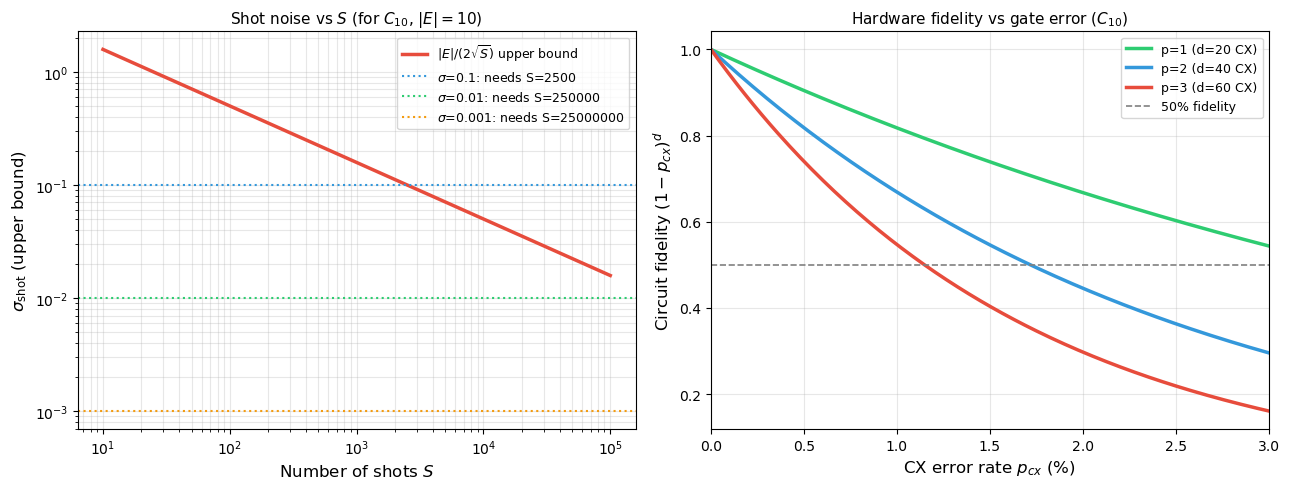

Error source summary for C10, p=2:
  Floating-point (statevector): ~4.2e-13
  Shot noise (S=1024):          ~0.156
  Optimisation (local minima):  problem-dependent, ~0.01-0.10
  Trotterisation:               0 (commuting terms)
  Hardware (p_cx=0.01):         fidelity=0.669


In [5]:
# ── Error budget visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Shot noise: std vs S for C10
S_vals = np.logspace(1, 5, 100)
E_edge = 10  # |E| for C10
sigma_shot = E_edge / (2*np.sqrt(S_vals))
axes[0].loglog(S_vals, sigma_shot, '#E74C3C', lw=2.5, label=r'$|E|/(2\sqrt{S})$ upper bound')
for target, color in [(0.1,'#3498DB'),(0.01,'#2ECC71'),(0.001,'#F39C12')]:
    S_needed = (E_edge/(2*target))**2
    axes[0].axhline(target, ls=':', color=color, lw=1.5, label=f'$\sigma$={target}: needs S={S_needed:.0f}')
axes[0].set_xlabel('Number of shots $S$', fontsize=12)
axes[0].set_ylabel(r'$\sigma_{\rm shot}$ (upper bound)', fontsize=12)
axes[0].set_title(r'Shot noise vs $S$ (for $C_{10}$, $|E|=10$)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, which='both')

# Hardware fidelity: (1-p_cx)^d
p_cx_vals = np.linspace(0, 0.03, 200)
for p_layers, color, label in [(1,'#2ECC71','p=1 (d=20 CX)'),(2,'#3498DB','p=2 (d=40 CX)'),(3,'#E74C3C','p=3 (d=60 CX)')]:
    d = 2 * p_layers * E_edge  # 2 CNOT per edge per layer
    fidelity = (1-p_cx_vals)**d
    axes[1].plot(p_cx_vals*100, fidelity, color=color, lw=2.5, label=label)
axes[1].axhline(0.5, color='gray', ls='--', lw=1.2, label='50% fidelity')
axes[1].set_xlabel('CX error rate $p_{cx}$ (%)', fontsize=12)
axes[1].set_ylabel('Circuit fidelity $(1-p_{cx})^d$', fontsize=12)
axes[1].set_title(r'Hardware fidelity vs gate error ($C_{10}$)', fontsize=11)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 3)
plt.tight_layout(); plt.show()

# Summary table
print('Error source summary for C10, p=2:')
print(f'  Floating-point (statevector): ~{60*2.2e-16*32:.1e}')
print(f'  Shot noise (S=1024):          ~{10/(2*np.sqrt(1024)):.3f}')
print(f'  Optimisation (local minima):  problem-dependent, ~0.01-0.10')
print(f'  Trotterisation:               0 (commuting terms)')
print(f'  Hardware (p_cx=0.01):         fidelity={(0.99)**40:.3f}')

---
## References

- Goemans, Williamson. *JACM* 42(6), 1995.
- Khot et al. *Optimal inapproximability for MAX-CUT.* JACM 2007.
- McClean et al. *Barren plateaus in quantum neural network training landscapes.* *Nature Commun.* 9, 2018.
- Wang et al. *Noise-induced barren plateaus.* *Nature Commun.* 12, 2021.
- Cerezo et al. *Cost-function-dependent barren plateaus.* *Nature Commun.* 12, 2021.
- Bravyi et al. *QAOA at high depth.* arXiv:2110.14206 (2021).
- Farhi, Goldstone, Gutmann. arXiv:1411.4028 (2014).